<a href="https://colab.research.google.com/github/FRosty799/UTS_Machine_Learning_1237050045/blob/main/UTS_machine_learning_1237050045.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#init dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris


In [33]:
#get file from github
!wget -q https://github.com/FRosty799/UTS_Machine_Learning_1237050045/raw/refs/heads/main/final__1_%20.csv -o final__1_ .csv

In [4]:
#upoad file
files.upload()

Saving final__1_ .csv to final__1_ .csv


{'final__1_ .csv': b'\xef\xbb\xbf"ID tanggapan","Tanggal pengiriman","Halaman terakhir","Bahasa utama","Biji","Tanggal mulai","Tanggal tindakan terakhir","Jenis Kelamin ","Usia","Asal Institusi","Status","Jabatan Akademik","Masa Kerja","Strata","Menurut Anda, hal apa yang pertama kali terlintas di pikiran Anda tatkala mendengar istilah Artificial Intelligent (AI)? ","Sejauh mana Anda memahami kondisi yang menuntut Anda menggunakan AI? ","Sejauh mana Anda memahami penggunaan AI secara bijak dan bertanggung jawab? ","Apakah Anda mengetahui bahwa Kementerian Pendidikan, Kebudayaan, Riset dan Teknologi Tahun 2024 telah menerbitkan dokumen Panduan Penggunaan Generative AI (GenAI) pada Pembelajaran di Perguruan Tinggi? ","Seberapa sering Anda menggunakan aplikasi AI untuk pekerjaan terkait dengan status Anda sebagai Dosen/Tenaga Kependidikan/Mahasiswa? ","Menurut Anda, seberapa besar ketergantungan Anda pada penggunaan AI untuk pekerjaan terkait status Anda? ","Penggunaan AI membantu Anda me

In [34]:
#load and map data
data = pd.read_csv('final__1_ .csv')

freq_map = {'Tidak Pernah': 1, 'Pernah': 2, 'Sering': 3, 'Sangat Sering': 4}
freq_map_understanding = {'Sangat Tidak Paham': 1, 'Tidak Paham': 2, 'Paham': 3, 'Sangat Paham': 4}

data['Freq_Score'] = data['Seberapa sering Anda menggunakan aplikasi AI untuk pekerjaan terkait dengan status Anda sebagai Dosen/Tenaga Kependidikan/Mahasiswa? '].map(freq_map)
data['Freq_Understanding'] = data['Sejauh mana Anda memahami kondisi yang menuntut Anda menggunakan AI? '].map(freq_map_understanding)

data_clean = data[['Freq_Understanding', 'Freq_Score']].dropna()

X = data_clean[['Freq_Score']]
y = data_clean[['Freq_Understanding']]

comparison_table = pd.crosstab(data_clean['Freq_Understanding'], data_clean['Freq_Score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Slope (impact): 0.2035
R-squared: (Correlation strength): 0.0807


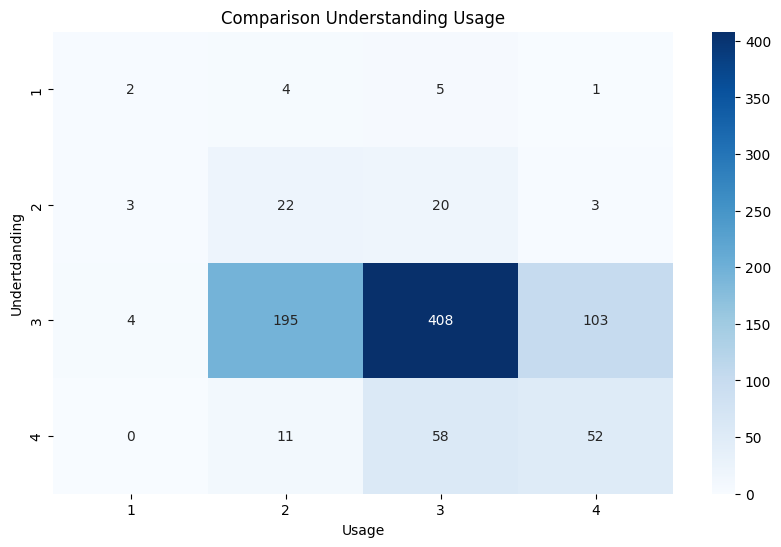

In [29]:
#Linear Regression Heatmap
model = LinearRegression()
model.fit(X, y)

slope_value = model.coef_.item()

print(f"Slope (impact): {slope_value:.4f}")
print(f"R-squared: (Correlation strength): {model.score(X, y):.4f}")

plt.figure(figsize=(10, 6))
sns.heatmap(comparison_table, annot=True, fmt='d', cmap='Blues')
plt.title('Comparison Understanding Usage')
plt.xlabel('Usage')
plt.ylabel('Undertdanding')
plt.show()

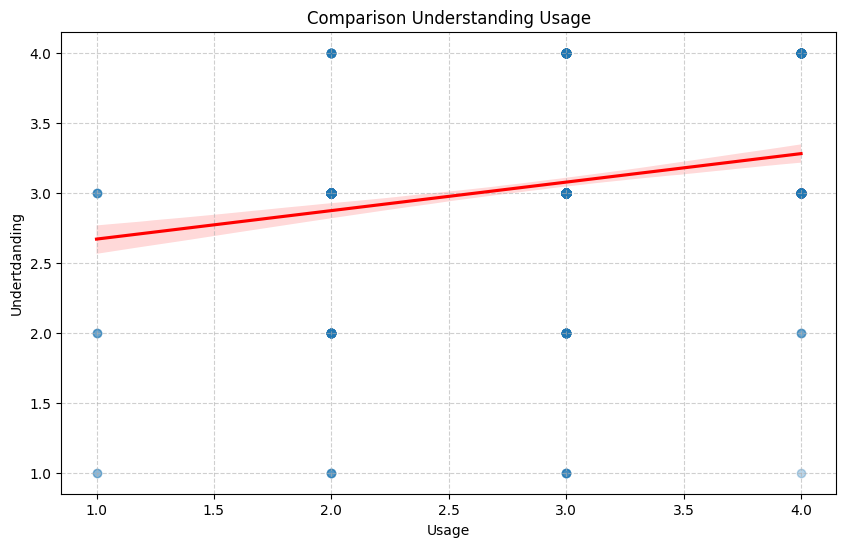

In [ ]:
#deprecated not heatmap its bad bad output
plt.figure(figsize=(10, 6))
sns.regplot(x= data_clean[['Freq_Score']], y= data_clean[['Freq_Understanding']], line_kws={'color': 'red'}, scatter_kws={'alpha':0.3})
plt.title('Comparison Understanding Usage')
plt.xlabel('Usage')
plt.ylabel('Undertdanding')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

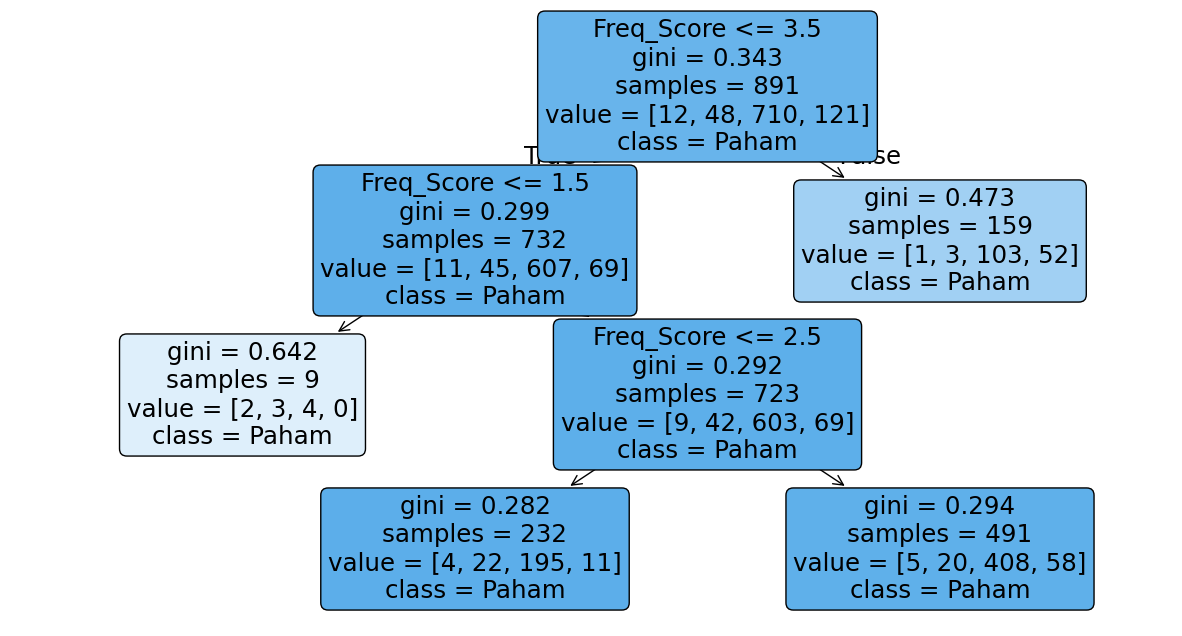

In [17]:
#Decision tree
X = data_clean[['Freq_Score']]
y = data_clean['Freq_Understanding']

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

class_names_str = [str(c) for c in clf.classes_]

label_map = {'1': 'Sangat Tidak Paham','2': 'Tidak Paham','3': 'Paham','4': 'Sangat Paham'}
class_names_labels = [label_map[c] for c in class_names_str]

# Plot the decision tree
plt.figure(figsize=(15,8))
plot_tree(clf, feature_names=['Freq_Score'], class_names=class_names_labels, filled=True, rounded=True)
plt.show

In [24]:
#support vector machine
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(kernel='rbf')
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print(f"Akurasi: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Akurasi: 81.01%
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00        12
           3       0.82      0.99      0.90       147
           4       0.00      0.00      0.00        18

    accuracy                           0.81       179
   macro avg       0.21      0.25      0.22       179
weighted avg       0.68      0.81      0.74       179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
#naive bayes
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Akurasi: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Akurasi: 82.12%
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00        12
           3       0.82      1.00      0.90       147
           4       0.00      0.00      0.00        18

    accuracy                           0.82       179
   macro avg       0.21      0.25      0.23       179
weighted avg       0.67      0.82      0.74       179



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning